# **Question No. 02**

In [35]:
import torch, sys, platform
print("Torch:", torch.__version__)
print("CUDA:", torch.cuda.is_available(), "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")
print("Python:", sys.version)
print("OS:", platform.platform())

Torch: 2.8.0+cu126
CUDA: True | Tesla T4
Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
OS: Linux-6.6.105+-x86_64-with-glibc2.35


In [36]:
import os, math, random, csv, json, zipfile, io
from pathlib import Path
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt

import torch, torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.utils.data import DataLoader, Subset
from torch.nn.utils import spectral_norm as SN
from torchvision import datasets, transforms, utils as tvu

# Repro
SEED = 123
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED); torch.backends.cudnn.benchmark = True
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Config
NZ, NGF, NDF, EMB = 128, 256, 64, 128
BATCH_SIZE, EPOCHS = 192, 120        # longer = better
LR_G, LR_S, BETAS = 4e-4, 2e-4, (0.5, 0.999)
FM_LAMBDA, EMA_DECAY = 0.25, 0.995
CAT, DOG = 3, 5
OUTDIR = Path("runs/q2_boost"); OUTDIR.mkdir(parents=True, exist_ok=True)

# Logging
from collections import defaultdict
LOG = defaultdict(list)
def log_scalar(name, val): LOG[name].append(float(val))
def save_log_npz_csv(prefix="training"):
    np.savez(OUTDIR/f"{prefix}.npz", **{k:np.array(v, np.float32) for k,v in LOG.items()})
    with open(OUTDIR/f"{prefix}.csv","w",newline="") as f:
        w=csv.writer(f); w.writerow(["step","name","value"])
        for name, arr in LOG.items():
            for i,v in enumerate(arr): w.writerow([i,name,v])

print("Device:", device)

Device: cuda


In [37]:
# === Inline visualization helpers ===
from IPython.display import clear_output, display
from PIL import Image

def show_png(path, title=None, figsize=(5,5)):
    img = Image.open(path)
    plt.figure(figsize=figsize)
    plt.imshow(img)
    plt.axis("off")
    if title: plt.title(title)
    plt.show()

LIVE_PREVIEW = True           # <- turn off if you don’t want live updates
PREVIEW_NROW = 10             # 10x10 grid when sampling

In [38]:
def make_dataloaders(data_root="./data", batch_size=BATCH_SIZE, num_workers=2):
    aug = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(0.2,0.2,0.2,0.1),
        transforms.ToTensor(),
        transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5)),
    ])
    plain = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5)),
    ])
    tr = datasets.CIFAR10(root=data_root, train=True,  download=True, transform=aug)
    te = datasets.CIFAR10(root=data_root, train=False, download=True, transform=plain)

    idx_tr = [i for i in range(len(tr)) if tr[i][1] in (CAT, DOG)]
    idx_te = [i for i in range(len(te)) if te[i][1] in (CAT, DOG)]
    dl_tr = DataLoader(Subset(tr, idx_tr), batch_size=batch_size, shuffle=True, drop_last=True,
                       num_workers=num_workers, pin_memory=True)
    dl_te = DataLoader(Subset(te, idx_te), batch_size=batch_size, shuffle=False,
                       num_workers=num_workers, pin_memory=True)
    return dl_tr, dl_te

dl_tr, dl_te = make_dataloaders()
len(dl_tr), len(dl_te)

(52, 11)

In [39]:
# https://arxiv.org/abs/2006.10738 minimal ops
def rand_brightness(x): return x + (torch.rand(x.size(0),1,1,1,device=x.device)-0.5)
def rand_saturation(x):
    x_mean = x.mean(dim=1,keepdim=True)
    return (x - x_mean)*(torch.rand(x.size(0),1,1,1,device=x.device)*2) + x_mean
def rand_contrast(x):
    x_mean = x.mean(dim=(1,2,3),keepdim=True)
    return (x - x_mean)*(torch.rand(x.size(0),1,1,1,device=x.device)+0.5) + x_mean
def rand_translation(x, ratio=0.125):
    B,C,H,W=x.shape; shift_x=int(W*ratio); shift_y=int(H*ratio)
    tx = torch.randint(-shift_x, shift_x+1, [B,1,1], device=x.device)
    ty = torch.randint(-shift_y, shift_y+1, [B,1,1], device=x.device)
    grid_y, grid_x = torch.meshgrid(torch.arange(H,device=x.device), torch.arange(W,device=x.device), indexing='ij')
    grid_x = (grid_x[None,None,:,:] - tx[:,:,None,None]).clamp(0,W-1)
    grid_y = (grid_y[None,None,:,:] - ty[:,:,None,None]).clamp(0,H-1)
    idx = grid_y*W + grid_x
    x = x.reshape(B,C,H*W); x = torch.gather(x, 2, idx.reshape(B,1,H*W).expand(-1,C,-1))
    return x.reshape(B,C,H,W)

def DiffAugment(x, policy='color,translation'):
    if 'color' in policy:
        x = rand_brightness(x); x = rand_saturation(x); x = rand_contrast(x)
    if 'translation' in policy:
        x = rand_translation(x)
    return x.clamp(-1,1)

In [40]:
class ResBlockG(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.upsample = nn.Upsample(scale_factor=2, mode='nearest')
        self.c1 = nn.Conv2d(in_ch, out_ch, 3, 1, 1, bias=False)
        self.c2 = nn.Conv2d(out_ch, out_ch, 3, 1, 1, bias=False)
        self.b1 = nn.BatchNorm2d(out_ch); self.b2 = nn.BatchNorm2d(out_ch)
        self.skip = nn.Conv2d(in_ch, out_ch, 1, 1, 0, bias=False)
    def forward(self, x):
        y = self.upsample(x)
        out = self.c1(y); out = self.b1(out); out = F.relu(out, True)
        out = self.c2(out); out = self.b2(out); out = F.relu(out, True)
        skip = self.skip(self.upsample(x))
        return out + skip

class Generator(nn.Module):
    def __init__(self, nz=NZ, base=128):
        super().__init__()
        self.nz = nz
        self.fc = nn.Linear(nz, base*4*4)
        self.rb1 = ResBlockG(base,   base)
        self.rb2 = ResBlockG(base,   base//2)   # 8x8 -> 16x16
        self.rb3 = ResBlockG(base//2, base//4)  # 16x16 -> 32x32
        self.to_rgb = nn.Conv2d(base//4, 3, 3, 1, 1)
    def forward(self, z):
        x = self.fc(z).view(z.size(0), -1, 4, 4)
        x = F.relu(x, True)
        x = self.rb1(x)
        x = self.rb2(x)
        x = self.rb3(x)
        x = torch.tanh(self.to_rgb(x))
        return x

class MinibatchStdDev(nn.Module):
    def __init__(self, group_size=16, eps=1e-8):
        super().__init__(); self.group_size=group_size; self.eps=eps
    def forward(self, x):
        N,C,H,W = x.shape; G = min(self.group_size, N)
        if N % G != 0: return x
        y = x.view(G,-1,C,H,W).var(dim=0, unbiased=False).add(self.eps).sqrt()
        y = y.mean(dim=(1,2,3), keepdim=True).repeat(G,1,H,W)
        return torch.cat([x,y],1)

class EmbedNet(nn.Module):
    def __init__(self, ndf=NDF, emb_dim=EMB):
        super().__init__()
        self.conv = nn.Sequential(
            SN(nn.Conv2d(3, ndf, 3, 1, 1)), nn.LeakyReLU(0.2, True),
            SN(nn.Conv2d(ndf, ndf, 4, 2, 1)), nn.LeakyReLU(0.2, True),   # 16x16
            SN(nn.Conv2d(ndf, ndf*2, 3, 1, 1)), nn.LeakyReLU(0.2, True),
            SN(nn.Conv2d(ndf*2, ndf*2, 4, 2, 1)), nn.LeakyReLU(0.2, True), # 8x8
            SN(nn.Conv2d(ndf*2, ndf*4, 3, 1, 1)), nn.LeakyReLU(0.2, True),
            SN(nn.Conv2d(ndf*4, ndf*4, 4, 2, 1)), nn.LeakyReLU(0.2, True), # 4x4
            MinibatchStdDev(),
        )
        self.fc = SN(nn.Linear((ndf*4+1)*4*4, emb_dim))
    def forward(self, x):
        h = self.conv(x)
        h_flat = h.view(x.size(0), -1)
        e = F.normalize(self.fc(h_flat), dim=1, eps=1e-6)
        return e, h_flat

class SimilarityNet(nn.Module):
    def __init__(self): super().__init__(); self.branch=EmbedNet(); self.scale=nn.Parameter(torch.tensor(10.0))
    def forward(self, x1, x2):
        e1,h1 = self.branch(x1); e2,h2 = self.branch(x2)
        cos = (e1*e2).sum(1, keepdim=True); logit = self.scale * cos
        return logit.squeeze(1), (h1,h2), (e1,e2)

In [41]:
@torch.no_grad()
def sample_grid(G, n=100, fname="grid.png"):
    z = torch.randn(n, NZ, device=device)
    x = G(z).clamp(-1,1)
    tvu.save_image(tvu.make_grid((x+1)/2, nrow=int(math.sqrt(n))), OUTDIR/fname)

@torch.no_grad()
def cosine_distributions(S, Gema, dl, max_batches=80):
    S.eval(); Gema.eval(); rr, rf = [], []
    for bi,(real,_) in enumerate(dl):
        real = real.to(device)
        fake = Gema(torch.randn(real.size(0), NZ, device=device))
        real2 = (real + 0.02*torch.randn_like(real)).clamp(-1,1)
        # apply DiffAug to align train/eval distribution
        real, real2, fake = DiffAugment(real), DiffAugment(real2), DiffAugment(fake)
        e1,_ = S.branch(real); e2,_ = S.branch(real2); ef,_ = S.branch(fake)
        rr.append((e1*e2).sum(1).cpu()); rf.append((e1*ef).sum(1).cpu())
        if bi+1>=max_batches: break
    rr, rf = torch.cat(rr).numpy(), torch.cat(rf).numpy()
    np.save(OUTDIR/"cosine_rr.npy", rr); np.save(OUTDIR/"cosine_rf.npy", rf)
    return rr, rf

def plot_losses():
    ls, lg = np.array(LOG["loss_S"],np.float32), np.array(LOG["loss_G"],np.float32)
    plt.figure(figsize=(6,3)); plt.plot(ls,label="S"); plt.plot(lg,label="G")
    plt.title("Loss history"); plt.legend(); plt.tight_layout()
    plt.savefig(OUTDIR/"loss_history.png",dpi=300); plt.show()

def plot_hists(rr, rf):
    plt.figure(figsize=(6,3))
    plt.title("Cosine similarity distributions")
    plt.hist(rr, bins=40, alpha=0.7, label="real-real")
    plt.hist(rf, bins=40, alpha=0.7, label="real-fake")
    plt.legend(); plt.tight_layout()
    plt.savefig(OUTDIR/"cosine_hists.png", dpi=300); plt.show()

@torch.no_grad()
def fid_like_in_S_space(S, Gema, dl, max_batches=100):
    S.eval(); Gema.eval(); R,F = [],[]
    for bi,(real,_) in enumerate(dl):
        real = real.to(device)
        fake = Gema(torch.randn(real.size(0), NZ, device=device))
        real, fake = DiffAugment(real), DiffAugment(fake)
        er,_ = S.branch(real); ef,_ = S.branch(fake)
        R.append(er.cpu()); F.append(ef.cpu())
        if bi+1>=max_batches: break
    R, F = torch.cat(R).numpy(), torch.cat(F).numpy()
    mu_r, mu_f = R.mean(0), F.mean(0)
    cov_r, cov_f = np.cov(R, rowvar=False), np.cov(F, rowvar=False)
    U,s,Vt = np.linalg.svd(cov_r @ cov_f)
    covmean = U @ np.diag(np.sqrt(np.clip(s,1e-12,None))) @ Vt
    diff = mu_r - mu_f
    return float(diff.dot(diff) + np.trace(cov_r + cov_f - 2*covmean))

@torch.no_grad()
def nearest_neighbor_montage(S, Gema, dl, K=16, fname="nn_pairs.png"):
    real,_ = next(iter(dl)); real = real.to(device)
    fake = Gema(torch.randn(K, NZ, device=device))
    real = DiffAugment(real); fake = DiffAugment(fake)
    er,_ = S.branch(real); ef,_ = S.branch(fake)
    idx = (ef @ er.t()).argmax(1)
    nearest = real[idx]
    grid = torch.cat([fake.clamp(-1,1), nearest.clamp(-1,1)],0)
    tvu.save_image(tvu.make_grid((grid+1)/2, nrow=K), OUTDIR/fname)
    return OUTDIR/fname

In [42]:
def pretrain_S(dl, epochs=5):
    S = SimilarityNet().to(device)
    opt = Adam(S.parameters(), lr=LR_S, betas=BETAS)
    bce = nn.BCEWithLogitsLoss()
    for ep in range(1,epochs+1):
        for real,_ in dl:
            real = real.to(device)
            real2 = (real + 0.02*torch.randn_like(real)).clamp(-1,1)
            z = torch.randn(real.size(0), NZ, device=device)
            # quick fake via noise to avoid bias from a weak G at this stage
            fake = (torch.rand_like(real)*2-1).to(device)

            # DiffAug on inputs to S
            r1 = DiffAugment(real); r2 = DiffAugment(real2); fk = DiffAugment(fake)

            y_rr = torch.ones(real.size(0), device=device)
            y_rf = torch.zeros(real.size(0), device=device)
            opt.zero_grad(set_to_none=True)
            log_rr,_,_ = S(r1, r2)
            log_rf,_,_ = S(r1, fk)
            loss = bce(log_rr, y_rr) + bce(log_rf, y_rf)
            loss.backward(); opt.step()
        print(f"[S-pretrain] epoch {ep} loss={loss.item():.4f}")
    return S

In [43]:
@torch.no_grad()
def update_ema(src, ema, decay=EMA_DECAY):
    for p,q in zip(ema.parameters(), src.parameters()):
        p.data.mul_(decay).add_(q.data, alpha=1-decay)

def train(epochs=EPOCHS):
    # warm up S
    S = pretrain_S(dl_tr, epochs=5)

    G = Generator().to(device)
    Gema = Generator().to(device); Gema.load_state_dict(G.state_dict())

    optG = Adam(G.parameters(), lr=LR_G, betas=BETAS)
    optS = Adam(S.parameters(), lr=LR_S, betas=BETAS)
    bce  = nn.BCEWithLogitsLoss()

    for ep in range(1, epochs+1):
        for real,_ in dl_tr:
            real = real.to(device)
            bs = real.size(0)

            # --- build pairs with DiffAug ---
            real2 = (real + 0.02*torch.randn_like(real)).clamp(-1,1)
            z = torch.randn(bs, NZ, device=device)
            fake_det = G(z).detach()

            r1 = DiffAugment(real); r2 = DiffAugment(real2); fk = DiffAugment(fake_det)

            # ===== S =====
            optS.zero_grad(set_to_none=True)
            y_rr = torch.ones(bs, device=device); y_rf = torch.zeros(bs, device=device)
            log_rr, (hr1,hr2), (er1,er2) = S(r1, r2)
            log_rf, (h1f,h2f), (ef1,ef2) = S(r1, fk)
            loss_S = bce(log_rr, y_rr) + bce(log_rf, y_rf)
            loss_S = loss_S + 0.001*(er1.std(0).mean()+er2.std(0).mean()).neg()
            loss_S.backward(); optS.step()

            # ===== G =====
            optG.zero_grad(set_to_none=True)
            z = torch.randn(bs, NZ, device=device)
            fake = G(z)
            r1 = DiffAugment(real); fk = DiffAugment(fake)
            log_rf, (h_real, h_fake), _ = S(r1, fk)

            adv = bce(log_rf, torch.ones_like(log_rf))
            fm  = F.l1_loss(h_fake.mean(0), h_real.mean(0))
            loss_G = adv + FM_LAMBDA * fm
            loss_G.backward(); optG.step()

            update_ema(G, Gema, EMA_DECAY)

            # log
            log_scalar("loss_S", loss_S.item())
            log_scalar("loss_G", loss_G.item())

        # end epoch: sample, save, live-display
        grid_path = OUTDIR / f"samples_ep{ep:03d}.png"
        sample_grid(Gema, n=PREVIEW_NROW*PREVIEW_NROW, fname=grid_path.name)
        save_log_npz_csv("training")
        print(f"[Epoch {ep:03d}] S={loss_S.item():.4f} | G={loss_G.item():.4f}")

        # if LIVE_PREVIEW:
        #     clear_output(wait=True)
        #     # small live dashboard: losses curve + latest grid
        #     # losses
        #     plt.figure(figsize=(6,3))
        #     plt.plot(LOG["loss_S"], label="S")
        #     plt.plot(LOG["loss_G"], label="G")
        #     plt.title("Loss history (live)")
        #     plt.legend(); plt.tight_layout(); plt.show()
        #     # samples
        #     show_png(grid_path, title=f"Samples @ epoch {ep}", figsize=(5,5))

    return G, S, Gema

In [44]:
G, S, Gema = train()

[S-pretrain] epoch 1 loss=1.6061
[S-pretrain] epoch 2 loss=0.0037
[S-pretrain] epoch 3 loss=0.0023
[S-pretrain] epoch 4 loss=0.0005
[S-pretrain] epoch 5 loss=0.0007
[Epoch 001] S=1.3013 | G=1.2927
[Epoch 002] S=1.1401 | G=1.0659
[Epoch 003] S=1.0098 | G=1.1289
[Epoch 004] S=1.0031 | G=1.0237
[Epoch 005] S=0.9752 | G=1.1063
[Epoch 006] S=1.0474 | G=0.9903
[Epoch 007] S=1.2693 | G=1.0436
[Epoch 008] S=1.0968 | G=0.9642
[Epoch 009] S=0.9886 | G=1.2486
[Epoch 010] S=1.0179 | G=1.1320
[Epoch 011] S=1.0411 | G=1.0294
[Epoch 012] S=0.9563 | G=0.9598
[Epoch 013] S=0.8973 | G=0.9254
[Epoch 014] S=0.9542 | G=1.0196
[Epoch 015] S=0.8958 | G=1.0032
[Epoch 016] S=0.9226 | G=0.8921
[Epoch 017] S=1.0879 | G=0.9232
[Epoch 018] S=1.0597 | G=1.0015
[Epoch 019] S=0.8418 | G=0.9990
[Epoch 020] S=0.8697 | G=0.9097
[Epoch 021] S=0.8321 | G=0.8916
[Epoch 022] S=0.9769 | G=1.0615
[Epoch 023] S=0.9204 | G=0.9274
[Epoch 024] S=0.9353 | G=1.0019
[Epoch 025] S=1.0738 | G=0.9963
[Epoch 026] S=0.9531 | G=1.0334
[Ep

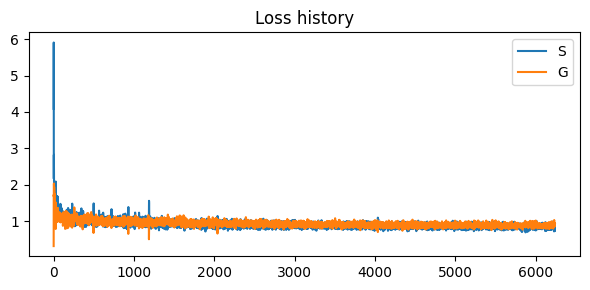

In [45]:
# 1) Loss curves
plot_losses()

Mean RR = 0.6252 | Mean RF = 0.0136 | GAP = 0.6115


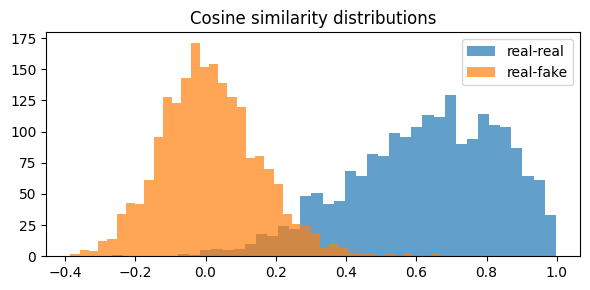

In [46]:
# 2) Cosine histograms + gap print
rr, rf = cosine_distributions(S, Gema, dl_te)
gap = float(rr.mean() - rf.mean())
print(f"Mean RR = {rr.mean():.4f} | Mean RF = {rf.mean():.4f} | GAP = {gap:.4f}")
plot_hists(rr, rf)

In [47]:
# 3) Final grid + nearest-neighbor montage
sample_grid(Gema, n=100, fname="final_grid.png")
nn_path = nearest_neighbor_montage(S, Gema, dl_te, K=16, fname="nn_pairs.png")

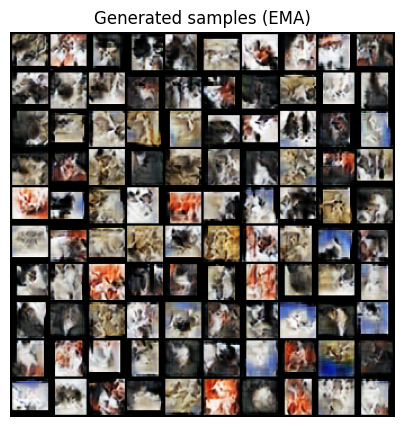

In [48]:
# 4) Show the saved PNGs inline (no need to re-generate)
show_png(OUTDIR/"final_grid.png", "Generated samples (EMA)", figsize=(5,5))

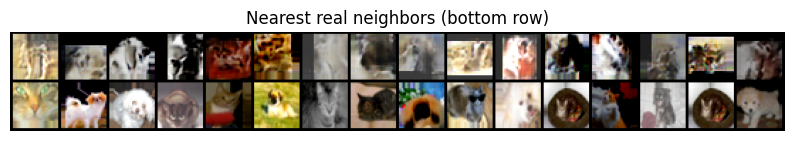

In [49]:
show_png(OUTDIR/"nn_pairs.png", "Nearest real neighbors (bottom row)", figsize=(10,3))

In [50]:
fidp = fid_like_in_S_space(S, Gema, dl_te)
txt = OUTDIR/"results.txt"
with open(txt, "w") as f:
    f.write("Custom Siamese-GAN (Cats&Dogs CIFAR-10) — Results\n")
    f.write(f"Timestamp: {datetime.now().isoformat()}\n\n")
    f.write(f"Mean RR = {rr.mean():.4f}\n")
    f.write(f"Mean RF = {rf.mean():.4f}\n")
    f.write(f"GAP (RR-RF) = {gap:.4f}\n")
    f.write(f"FID-like proxy (S-embeddings) = {fidp:.4f}\n")
    f.write("\nArtifacts:\n")
    f.write("- loss_history.png\n- cosine_hists.png\n- final_grid.png\n- nn_pairs.png\n")
print("Saved:", txt)

Saved: runs/q2_boost/results.txt


In [51]:
# Inline preview of the txt
from IPython.display import Markdown
print(txt.read_text())

Custom Siamese-GAN (Cats&Dogs CIFAR-10) — Results
Timestamp: 2025-11-01T23:33:30.271109

Mean RR = 0.6252
Mean RF = 0.0136
GAP (RR-RF) = 0.6115
FID-like proxy (S-embeddings) = 0.2032

Artifacts:
- loss_history.png
- cosine_hists.png
- final_grid.png
- nn_pairs.png

